Christian Thede
CNN Model

Notes:
1. Used AI for mounting and dealing with colab and google drive (and still had a ton of issues). Also eventually used AI to help me figure out that I had the no cuda version of pytorch installed and fix it.
2. Model trained on MNIST
3. Hardware: T4 GPU from Colab
4. Sources:
optimizer: https://keras.io/api/optimizers/
learning rate: https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html
data: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [23]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Mount Google Drive
# Mount Google Drive if running in Colab; otherwise use the local working directory
try:
    from google.colab import drive
    drive.mount("/content/gdrive")
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")
    OUTPUT_DIR = DRIVE_ROOT / "Colab Notebooks" / "Output"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    drive.mount("/content/gdrive")
except ModuleNotFoundError:
    DRIVE_ROOT = Path.cwd()


DRIVE_ROOT = Path("/content/gdrive/MyDrive")
OUTPUT_DIR = DRIVE_ROOT / "Colab Notebooks" / "Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Data
Load MNIST from torchvision, normalize pixel values, and split into batches

In [2]:
print("Preparing data...")
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,))  # 1 channel for grayscale
])

# download data
train_dataset = torchvision.datasets.MNIST(root='./MNIST', train=True,  transform=normalize_transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root='./MNIST', train=False, transform=normalize_transform, download=True)

# group images into batches
batch_size   = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size)

Preparing data...


### Model
3 layer CNN
- conv layers extract features
- maxpool layers reduce spatial size (prevent overfitting)
- fully connected layers at the end to digit predictions

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 28x28 -> 14x14
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 14x14 -> 7x7
            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),  # 7x7   -> 3x3
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 3 * 3, 512),
            torch.nn.ReLU(),  # 64*3*3=576
            torch.nn.Linear(512, 10)  # outpus 1 score per digit classe
        )

    def forward(self, x):
        return self.model(x)


# gpu acceleration
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")
model = CNN().to(device)
print(torch.version.cuda)

Using device: cuda
12.8


### Train
Train for 30 epochs using Adam optimizer and a learning rate scheduler

Training...
Epoch 1/50: loss = 0.0325 | accuracy = 98.97%
Epoch 2/50: loss = 0.0267 | accuracy = 99.19%
Epoch 3/50: loss = 0.0241 | accuracy = 99.25%
Epoch 4/50: loss = 0.0223 | accuracy = 99.31%
Epoch 5/50: loss = 0.0218 | accuracy = 99.36%
Epoch 6/50: loss = 0.0168 | accuracy = 99.48%
Epoch 7/50: loss = 0.0142 | accuracy = 99.62%
Epoch 8/50: loss = 0.0136 | accuracy = 99.65%
Epoch 9/50: loss = 0.0132 | accuracy = 99.67%
Epoch 10/50: loss = 0.0128 | accuracy = 99.69%
Epoch 11/50: loss = 0.0118 | accuracy = 99.70%
Epoch 12/50: loss = 0.0108 | accuracy = 99.77%
Epoch 13/50: loss = 0.0104 | accuracy = 99.78%
Epoch 14/50: loss = 0.0101 | accuracy = 99.79%
Epoch 15/50: loss = 0.0100 | accuracy = 99.81%
Epoch 16/50: loss = 0.0094 | accuracy = 99.79%
Epoch 17/50: loss = 0.0089 | accuracy = 99.83%
Epoch 18/50: loss = 0.0088 | accuracy = 99.85%
Epoch 19/50: loss = 0.0086 | accuracy = 99.86%
Epoch 20/50: loss = 0.0086 | accuracy = 99.86%
Epoch 21/50: loss = 0.0079 | accuracy = 99.87%
Epoch 22/5

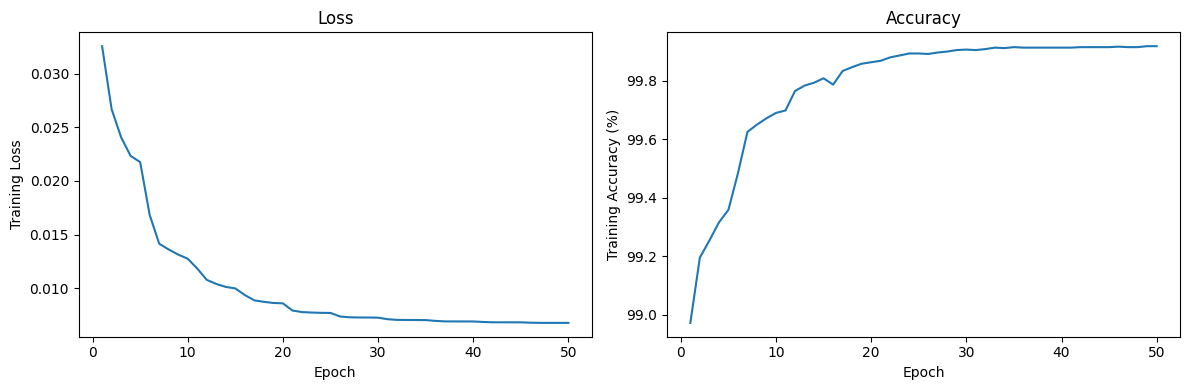

Model saved to \content\gdrive\MyDrive\Colab Notebooks\Output\mnist_cnn.pth


In [ ]:
num_epochs    = 30
learning_rate = 0.001
weight_decay  = 0.001 # changed from .005 because it was plateauing early and the scheduler was pretty agressive
criterion     = torch.nn.CrossEntropyLoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # learning rate decay
# with step size 5 and gamma .5 the learning rate is halved every 5 epochs

print("Training...")
train_loss_list = []
train_acc_list  = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}:", end=" ")
    train_loss    = 0
    correct       = 0
    total         = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    train_loss_list.append(train_loss / len(train_loader))
    train_acc_list.append(100 * correct / total)
    print(f"loss = {train_loss_list[-1]:.4f} | accuracy = {train_acc_list[-1]:.2f}%")
    scheduler.step()  # added steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), train_loss_list)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Loss")

ax2.plot(range(1, num_epochs + 1), train_acc_list)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Training Accuracy (%)")
ax2.set_title("Accuracy")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png")
plt.show()

torch.save(model.state_dict(), OUTPUT_DIR / "mnist_cnn.pth")
print("Model saved to", OUTPUT_DIR / "mnist_cnn.pth")

Loading a Model

In [ ]:
from pathlib import Path

# path to model
MODEL_PATH = Path(r" model path")  # model path here ----------

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print("Loaded model from", MODEL_PATH)

Loaded model from c:\Users\cthed\Desktop\ApolloAgent\486-Final-Project\Code\CNN\mnist_cnn.pth


### Test

In [40]:

nums = torchvision.datasets.ImageFolder(
    Path("Nums"),
    transform=torchvision.transforms.Compose([
        torchvision.transforms.Grayscale(num_output_channels=1),
        torchvision.transforms.Resize((28, 28)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,), (0.5,))
    ])
)
loader = torch.utils.data.DataLoader(nums, batch_size=128, shuffle=False)

correct = total = 0
with torch.no_grad():
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = loaded_model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy on Nums Dataset: {100 * correct / total:.2f}%")

Accuracy on Nums Dataset: 93.33%


Attempting Validation Training

In [15]:
# just screwing around with some early stopping and validation training
from torch.utils.data import random_split, DataLoader
import math, torch

LOCAL_MODEL_PATH = Path("mnist_cnn.pth")

val_frac = 0.1
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-3
patience = 5

n_total = len(train_dataset)
n_val = int(math.floor(n_total * val_frac))
n_train = n_total - n_val
train_subset, val_subset = random_split(train_dataset, [n_train, n_val],generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=2)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_loss = float("inf")
epochs_no_improve = 0

print(f"Training for up to {num_epochs} epochs (val_frac={val_frac}, patience={patience})")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100.0 * correct / total

    # validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100.0 * correct / total

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} — train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

    # check against best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), LOCAL_MODEL_PATH)
        print("  Saved best model to", LOCAL_MODEL_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping (no improvement in {patience} epochs).")
            break

# load best weights into model after training
model.load_state_dict(torch.load(LOCAL_MODEL_PATH, map_location=device))
print("Training finished, best model loaded from", LOCAL_MODEL_PATH)

Training for up to 30 epochs (val_frac=0.1, patience=5)
Epoch 1/30 — train_loss=0.0216 train_acc=99.33% | val_loss=0.0250 val_acc=99.32%
  Saved best model to mnist_cnn.pth
Epoch 2/30 — train_loss=0.0193 train_acc=99.38% | val_loss=0.0278 val_acc=99.00%
Epoch 3/30 — train_loss=0.0196 train_acc=99.41% | val_loss=0.0287 val_acc=98.97%
Epoch 4/30 — train_loss=0.0192 train_acc=99.41% | val_loss=0.0263 val_acc=99.12%
Epoch 5/30 — train_loss=0.0187 train_acc=99.43% | val_loss=0.0241 val_acc=99.30%
  Saved best model to mnist_cnn.pth
Epoch 6/30 — train_loss=0.0119 train_acc=99.66% | val_loss=0.0234 val_acc=99.23%
  Saved best model to mnist_cnn.pth
Epoch 7/30 — train_loss=0.0119 train_acc=99.69% | val_loss=0.0264 val_acc=99.23%
Epoch 8/30 — train_loss=0.0124 train_acc=99.67% | val_loss=0.0237 val_acc=99.30%
Epoch 9/30 — train_loss=0.0127 train_acc=99.65% | val_loss=0.0266 val_acc=99.12%
Epoch 10/30 — train_loss=0.0115 train_acc=99.69% | val_loss=0.0262 val_acc=99.17%
Epoch 11/30 — train_loss=